<a href="https://colab.research.google.com/github/KhoirotunNisa25/PCVK_Ganjil_2025/blob/main/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Modul 10: Thresholding, Segmentasi Sederhana

## D. Tugas Praktikum

In [1]:
# akses file
from google.colab import drive

### 2. Import Library

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

### 3. Global Threshold

Buat Global Threshold (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV), dengan
threshold= 170, secara manual sesuai dengan deskripsi dari grafik yang ditunjukkan di
atas.

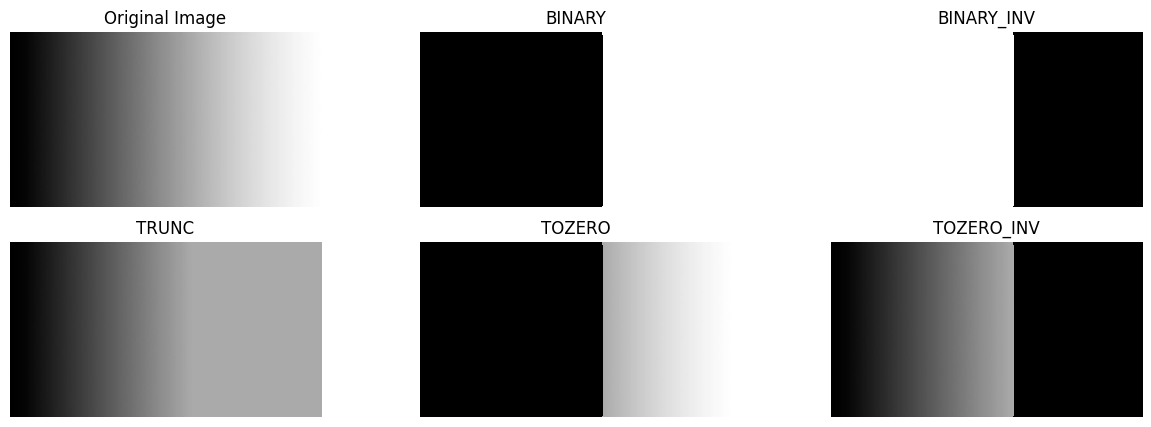

In [20]:
img_path = '/content/drive/MyDrive/PCVK/Images/gradient.jpg'

img = cv2.imread(img_path)
th = 170

ret1, th_binary = cv2.threshold(img, th, 255, cv2.THRESH_BINARY)
ret2, th_binary_inv = cv2.threshold(img, th, 255, cv2.THRESH_BINARY_INV)
ret3, th_trunc = cv2.threshold(img, th, 255, cv2.THRESH_TRUNC)
ret4, th_tozero = cv2.threshold(img, th, 255, cv2.THRESH_TOZERO)
ret5, th_tozero_inv = cv2.threshold(img, th, 255, cv2.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, th_binary, th_binary_inv, th_trunc, th_tozero, th_tozero_inv]

plt.figure(figsize=(15,5))
for i in range(len(images)):
    plt.subplot(2,3,i+1);
    plt.imshow(images[i],'gray',interpolation='nearest');
    plt.title(titles[i]);
    plt.xticks([]),plt.yticks([])
    plt.axis('off')
plt.show()


### 4. Otsu Thresholding

Buat Otsu Thresholding tanpa menggunakan Library. Tampilkan juga nilai threshold
saat anda gunakan Otsu’s, seperti terlihat pada gambar hasil berikut. (gunakan image
balloon.jpg agar terlihat beda antara hasil otsu’s dengan global threshold biasa)

Global threshold = 90
Otsu's threshold (manual) = 172


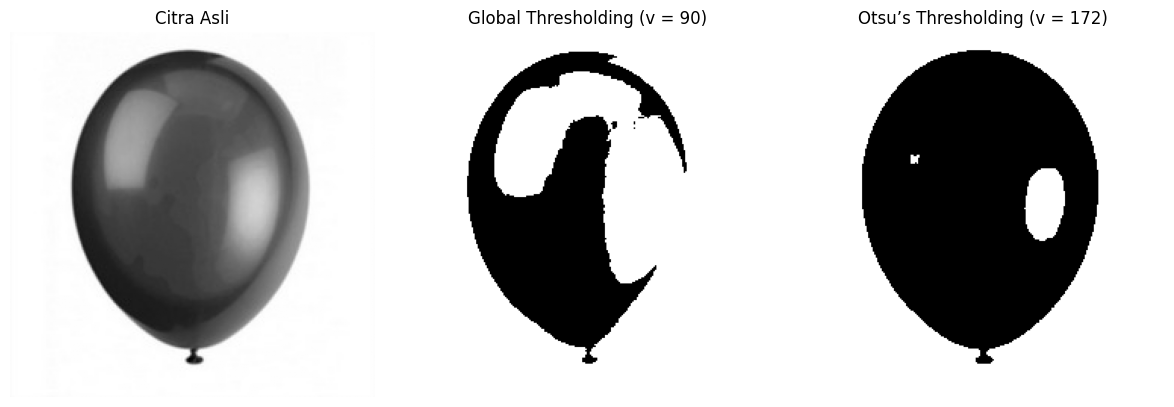

In [24]:
# Load citra
img_path = '/content/drive/MyDrive/PCVK/Images/balon.jpg'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"File tidak ditemukan: {img_path}")

# Global Thresholding (nilai acuan: 90)
global_thresh = 90
_, th_global = cv2.threshold(img, global_thresh, 255, cv2.THRESH_BINARY)

# Implementasi Otsu TANPA library
hist = cv2.calcHist([img],[0],None,[256],[0,256]).ravel()
total = img.size
omega = np.cumsum(hist)                 # cumulative class probabilities
mu = np.cumsum(hist * np.arange(256))   # cumulative mean
mu_t = mu[-1]

within_vars = np.zeros(256)
for t in range(256):
    w0 = omega[t]
    w1 = total - w0
    if w0 == 0 or w1 == 0:
        within_vars[t] = np.inf
        continue
    mu0 = mu[t] / w0
    mu1 = (mu_t - mu[t]) / w1
    var0 = np.sum(((np.arange(t+1) - mu0)**2) * hist[:t+1]) / w0
    var1 = np.sum(((np.arange(t+1,256) - mu1)**2) * hist[t+1:]) / w1
    within_vars[t] = (w0/total)*var0 + (w1/total)*var1

otsu_t = int(np.argmin(within_vars))
_, th_otsu = cv2.threshold(img, otsu_t, 255, cv2.THRESH_BINARY)

print(f"Global threshold = {global_thresh}")
print(f"Otsu's threshold (manual) = {otsu_t}")

# Tampilkan
titles = [
    'Citra Asli',
    f'Global Thresholding (v = {global_thresh})',
    f"Otsu’s Thresholding (v = {otsu_t})"
]
images = [img, th_global, th_otsu]

plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

### 5. Histogram dari Citra Tersegmentasi

Buat histogram dari citra tersegmentasi, Histogram hanya pada foreground image
saja. Gunakan image tobacco.jpg yang sudah disediakan di folder images.
Petunjuk:
- anda dapat gunakan cv.calcHist untuk menampilkan histogram.
- Buka link berikut https://opencv-tutorial.readthedocs.io/en/latest/histogram/histogram.html
- Dari link tersebut perhatikan bahwa cv.calcHist memiliki salah satu parameter
yaitu mask. Jika diset None, maka keseluruhan image akan dihitung
histogramnya. Jika kita tentukan mask, maka hanya bagian image yang
dimasking warna putih yang akan dihitung histogramnya (dari contoh
dibawah dinamakan dengan Citra Segment).

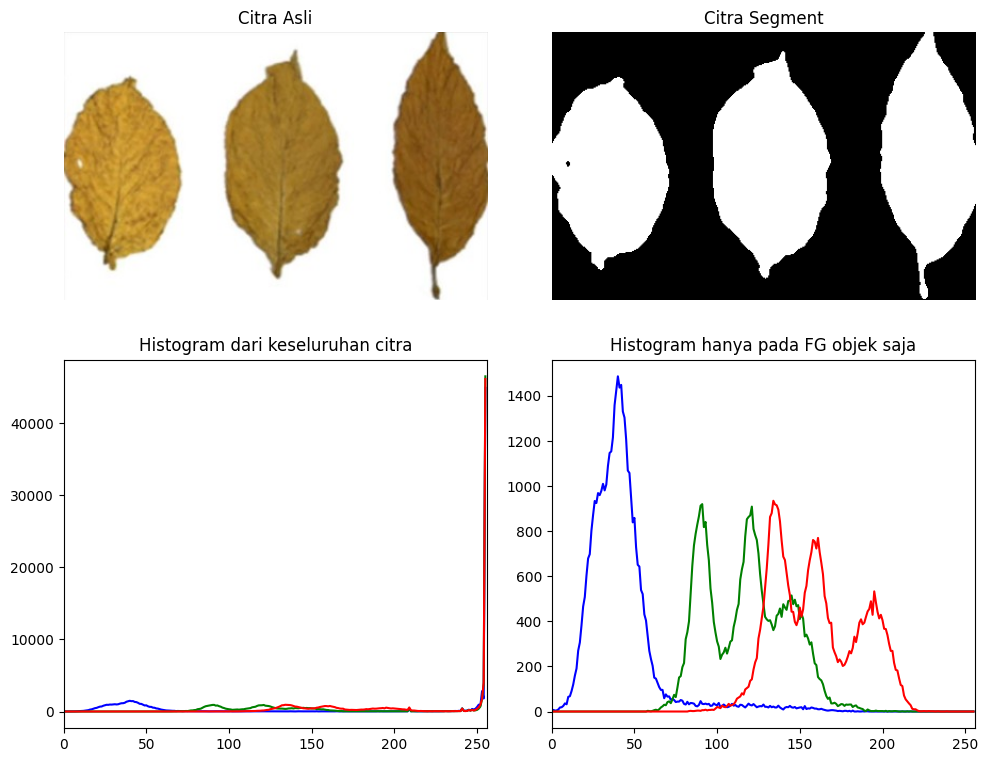

In [31]:
# Load citra
img_path = '/content/drive/MyDrive/PCVK/Images/tobacco.jpg'
img_color = cv2.imread(img_path)

# Konversi ke grayscale
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# Balik threshold agar daun putih (foreground), background hitam
_, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Haluskan tepi daun
mask = cv2.medianBlur(mask, 5)

# Hitung histogram seluruh citra (tanpa mask)
color_channels = ('b','g','r')
plt.figure(figsize=(10,8))

# Baris 1 kolom 1 — Citra Asli
plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

# Baris 1 kolom 2 — Citra Segment
plt.subplot(2,2,2)
plt.imshow(mask, cmap='gray')
plt.title('Citra Segment')
plt.axis('off')

# Baris 2 kolom 1 — Histogram keseluruhan citra
plt.subplot(2,2,3)
for i, col in enumerate(color_channels):
    hist = cv2.calcHist([img_color], [i], None, [256], [0,256])
    plt.plot(hist, color=col)
plt.title('Histogram dari keseluruhan citra')
plt.xlim([0,256])

# Baris 2 kolom 2 — Histogram hanya foreground saja
plt.subplot(2,2,4)
for i, col in enumerate(color_channels):
    hist_fg = cv2.calcHist([img_color], [i], mask, [256], [0,256])
    plt.plot(hist_fg, color=col)
plt.title('Histogram hanya pada FG objek saja')
plt.xlim([0,256])

plt.tight_layout()
plt.show()

### 6. Segmentasi Warna

Lakukan segmentasi warna pada image "peppers.jpg", munculkan hanya warna yang
kuning saja. (Petunjuk: anda dapat gunakan K-Means untuk menampilkan hanya
warna tertentu saja)

Centroid warna (RGB):
Cluster 0: [192 143 110]
Cluster 1: [ 92 117  20]
Cluster 2: [178  36  31]
Cluster 3: [250 206   3]
Cluster 4: [252 251 249]

Cluster kuning terdekat: 3 -> [250 206   3]


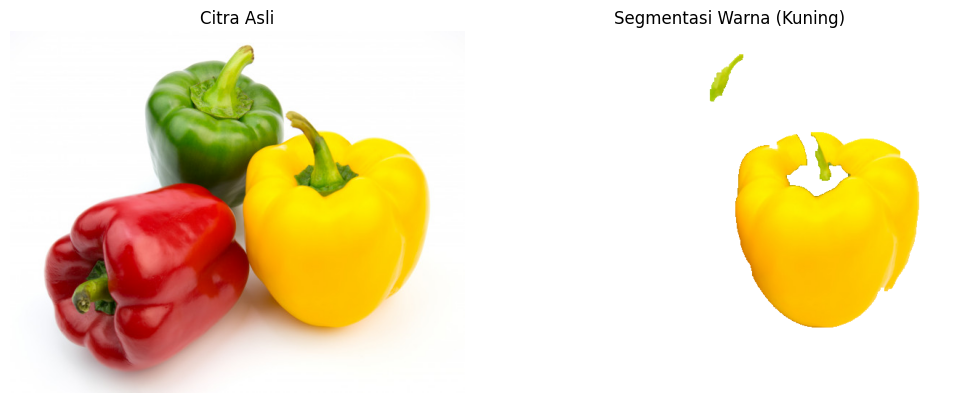

In [39]:
#  Load image
img_path = '/content/drive/MyDrive/PCVK/Images/peppers.jpg'
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"File tidak ditemukan: {img_path}")

# Konversi ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
Z = img_rgb.reshape((-1,3))
Z = np.float32(Z)

# K-Means clustering
K = 5  # jumlah cluster
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
labels = labels.flatten()

# Tentukan cluster yang paling mendekati warna kuning (255, 255, 0)
target_color = np.array([255, 255, 0])
distances = np.linalg.norm(centers - target_color, axis=1)
yellow_cluster_idx = np.argmin(distances)

print("Centroid warna (RGB):")
for i, c in enumerate(centers):
    print(f"Cluster {i}: {c}")
print(f"\nCluster kuning terdekat: {yellow_cluster_idx} -> {centers[yellow_cluster_idx]}")

# Buat mask untuk cluster kuning =
mask = (labels == yellow_cluster_idx).astype(np.uint8) * 255
mask = mask.reshape(img_rgb.shape[:2])

# Bersihkan noise kecil
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Tampilkan hanya bagian kuning
result = np.full_like(img_rgb, 255)  # background putih
result[mask == 255] = img_rgb[mask == 255]

# Hasil
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result)
plt.title('Segmentasi Warna (Kuning)')
plt.axis('off')

plt.tight_layout()
plt.show()


Kendala:
- Warna objek kuning pada paprika memiliki variasi intensitas akibat bayangan dan pantulan cahaya.(Segmentasi warna kuning tidak bisa 100% akurat, masih ada warna hijau yang muncul sedikit) Sehingga menyebabkan sebagian piksel salah klasifikasi. Perbaikan bisa dilakukan dengan menambah pra-prosesing (Penambahan filter morfologi)
- Cara menentukan cluster (k) untuk K-means masih manual dan kira-kira (Belum memakai elbow)

### 7. Lakukan thresholding biner `crossword.jpg`

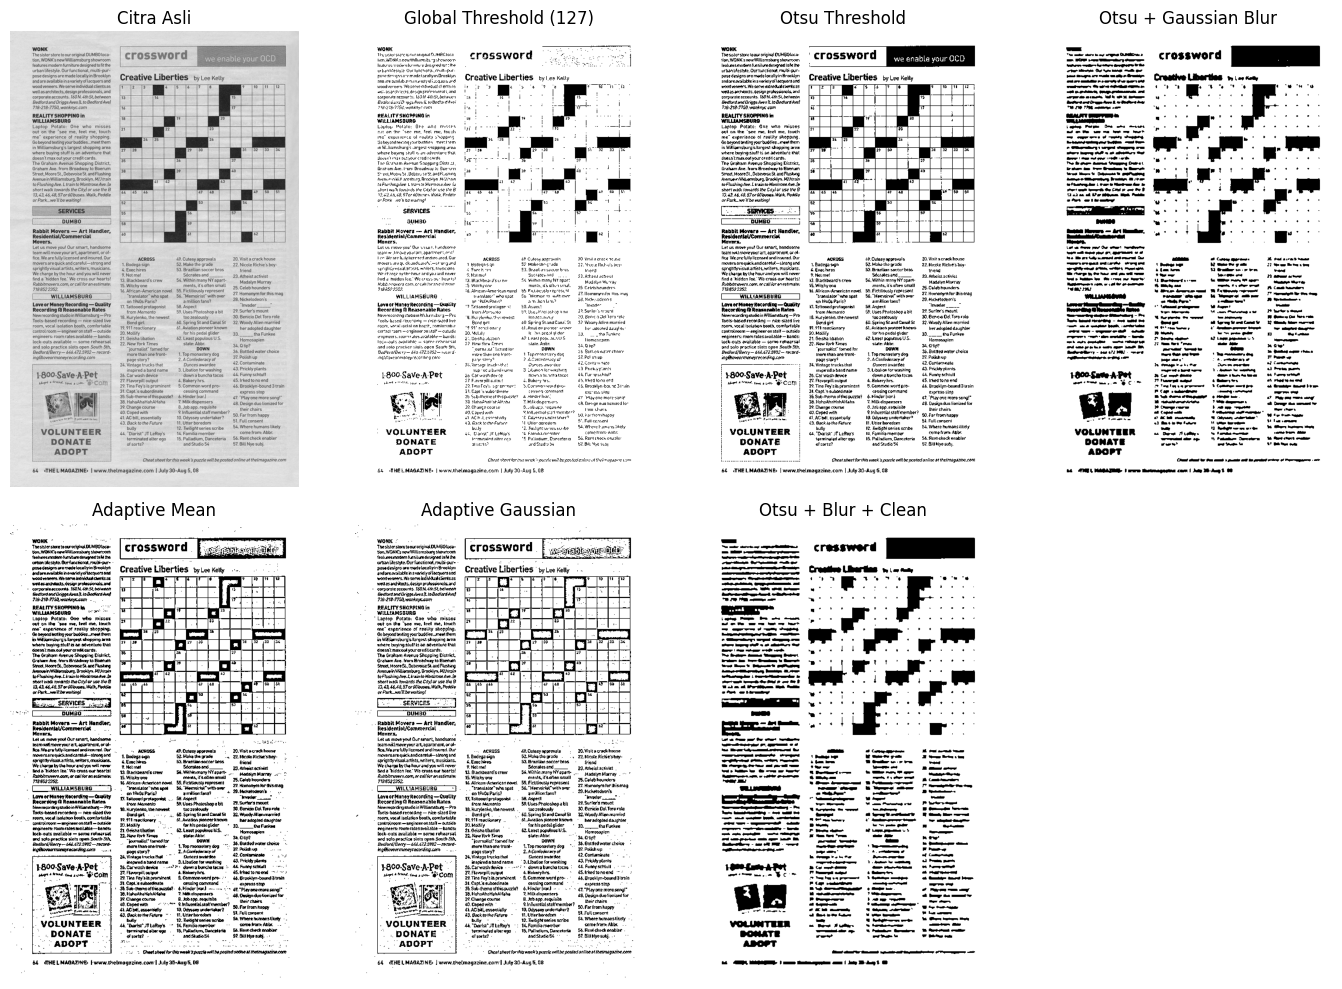

In [43]:
# === 1. Load citra crossword ===
img_path = '/content/drive/MyDrive/PCVK/Images/crossword.jpg'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# === 2. Coba beberapa metode threshold ===

# Global threshold (nilai tetap)
_, th_global = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Otsu threshold langsung
_, th_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Otsu setelah Gaussian blur (biasanya paling bersih)
blur = cv2.GaussianBlur(img, (5,5), 0)
_, th_otsu_blur = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Adaptive Mean dan Adaptive Gaussian
th_mean = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 15, 10)
th_gauss = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 10)

# === 3. Bersihkan noise kecil pada hasil terbaik (optional)
kernel = np.ones((3,3), np.uint8)
th_clean = cv2.morphologyEx(th_otsu_blur, cv2.MORPH_OPEN, kernel)

# === 4. Tampilkan hasil perbandingan ===
titles = [
    'Citra Asli',
    'Global Threshold (127)',
    'Otsu Threshold',
    'Otsu + Gaussian Blur',
    'Adaptive Mean',
    'Adaptive Gaussian',
    'Otsu + Blur + Clean'
]
images = [img, th_global, th_otsu, th_otsu_blur, th_mean, th_gauss, th_clean]

plt.figure(figsize=(14,10))
for i in range(len(images)):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

Yang terbaik adalah Otsu Threshold. Grid jelas dan huruf terbaca (walaupun masih sedikit ada noise)